In [1]:
import time
from tqdm import tqdm
import pygame
from pygame import gfxdraw
from matplotlib import pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from scipy.integrate import solve_ivp
from os import path
import os
from math import cos, sin
import torch
from torch import nn
from copy import deepcopy

c:\Users\20220694\OneDrive - TU Eindhoven\Desktop\TUe Master\ML for Systems and Control\Assignment\UnbalancedDisk\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.12.11)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Environment 

In [2]:

class UnbalancedDisk(gym.Env):
    '''
    UnbalancedDisk
    th =            
                  +-pi
                    |
           pi/2   ----- -pi/2
                    |
                    0  = starting location
    '''
    def __init__(self, umax=3., dt = 0.025, render_mode='human'):
        ############# start do not edit  ################
        self.omega0 = 11.339846957335382
        self.delta_th = 0
        self.gamma = 1.3328339309394384
        self.Ku = 28.136158407237073
        self.Fc = 6.062729509386865
        self.coulomb_omega = 0.001

        # self.g = 9.80155078791343
        # self.J = 0.000244210523960356
        # self.Km = 10.5081817407479
        # self.I = 0.0410772235841364
        # self.M = 0.0761844495320390
        # self.tau = 0.397973147009910
        ############# end do not edit ###################

        self.umax = umax
        self.dt = dt #time step
 

        # change anything here (compilable with the exercise instructions)
        # self.action_space = spaces.Box(low=-umax,high=umax,shape=tuple()) #continuous
        self.action_space = spaces.Discrete(5) #discrete
        self.action_map = np.array([-umax, -umax/2, 0.0, umax/2, umax]) #discrete
        # self.action_map = np.array([-umax, -umax/2, -umax/3, 0.0, umax/3, umax/2, umax]) 

        low = [-float('inf'),-40] 
        high = [float('inf'),40]
        self.observation_space = spaces.Box(low=np.array(low,dtype=np.float32),high=np.array(high,dtype=np.float32),shape=(2,))

        
        self.render_mode = render_mode
        self.viewer = None
        self.u = 0 #for visual
        self.reset()

    def reward_fun(self):
            return np.exp(-(self.th%(2*np.pi)-np.pi)**2/(2*(np.pi/7)**2)) #example reward function, change this!
            
    def step(self, action):
        """
        action: [0, 1, 2, 3, 4] -> [-umax, -umax/2, 0.0, umax/2, umax]
        """
        #convert action to u
        # self.u = action #continuous
        self.u = self.action_map[action] #discrete
        # self.u = [-3,-1,0,1,3][action] #discrate
        # self.u = [-3,3][action] #discrate

        ##### Start Do not edit ######
        self.u = np.clip(self.u,-self.umax,self.umax)
        def f(t,y):
            th, omega = y
            dthdt = omega
            friction = self.gamma*omega + self.Fc*np.tanh(omega/self.coulomb_omega)
            domegadt = -self.omega0**2*np.sin(th+self.delta_th) - friction + self.Ku*self.u
            return np.array([dthdt, domegadt])
        sol = solve_ivp(f,[0,self.dt],[self.th,self.omega]) #integration
        self.th, self.omega = sol.y[:,-1]
        ##### End do not edit   #####

        reward = self.reward_fun()
        return self.get_obs(), reward, False, False, {}
         
    def reset(self,seed=None, options=None):
        self.th = np.random.normal(loc=0,scale=0.001)
        self.omega = np.random.normal(loc=0,scale=0.001)
        self.u = 0
        return self.get_obs(), {}

    def get_obs(self):
        self.th_noise = self.th + np.random.normal(loc=0,scale=0.001) #do not edit
        self.omega_noise = self.omega + np.random.normal(loc=0,scale=0.001) #do not edit
        return np.array([self.th_noise, self.omega_noise])

    def render(self):
        screen_width = 500
        screen_height = 500

        th = self.th
        omega = self.omega #x = self.state

        if self.viewer is None:
            pygame.init()
            pygame.display.init()
            self.viewer = pygame.display.set_mode((screen_width, screen_height))

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))
        
        gfxdraw.filled_circle( #central blue disk
            self.surf,
            screen_width//2,
            screen_height//2,
            int(screen_width/2*0.65*1.3),
            (32,60,92),
        )
        gfxdraw.filled_circle( #small midle disk
            self.surf,
            screen_width//2,
            screen_height//2,
            int(screen_width/2*0.06*1.3),
            (132,132,126),
        )
        

        r = screen_width//2*0.40*1.3
        gfxdraw.filled_circle( #disk
            self.surf,
            int(screen_width//2-sin(th)*r), #is direction correct?
            int(screen_height//2-cos(th)*r),
            int(screen_width/2*0.22*1.3),
            (155,140,108),
        )
        gfxdraw.filled_circle( #small nut
            self.surf,
            int(screen_width//2-sin(th)*r), #is direction correct?
            int(screen_height//2-cos(th)*r),
            int(screen_width/2*0.22/8*1.3),
            (71,63,48),
        )
        
        fname = path.join(path.dirname(__file__), "clockwise.png")
        self.arrow = pygame.image.load(fname)
        if self.u:
            if isinstance(self.u, (np.ndarray,list)):
                if self.u.ndim==1:
                    u = self.u[0]
                elif self.u.ndim==0:
                    u = self.u
                else:
                    raise ValueError(f'u={u} is not the correct shape')
            else:
                u = self.u
            arrow_size = abs(float(u)/self.umax*screen_height)*0.25
            Z = (arrow_size, arrow_size)
            arrow_rot = pygame.transform.scale(self.arrow,Z)
            if self.u<0:
                arrow_rot = pygame.transform.flip(arrow_rot, True, False)
                
        self.surf = pygame.transform.flip(self.surf, False, True)
        self.viewer.blit(self.surf, (0, 0))
        if self.u:
            self.viewer.blit(arrow_rot, (screen_width//2-arrow_size//2, screen_height//2-arrow_size//2))
        if self.render_mode == "human":
            pygame.event.pump()
            pygame.display.flip()

        return True

    def close(self):
        if self.viewer is not None:
            import pygame

            pygame.display.quit()
            pygame.quit()
            self.isopen = False
            self.viewer = None



In [30]:

class UnbalancedDisk_sincos(UnbalancedDisk):
    """
    Observations = [sin(th), cos(th), omega]
    Ranges:
    sin(th) in [-1,1]
    cos(th) in [-1,1]
    omega in [-40,40]
    """
    
    def __init__(self, umax=3., dt = 0.025):
        super(UnbalancedDisk_sincos, self).__init__(umax=umax, dt=dt)
        low = [-1,-1,-40.] 
        high = [1,1,40.]
        self.observation_space = spaces.Box(low=np.array(low,dtype=np.float32),high=np.array(high,dtype=np.float32),shape=(3,))

    def reward_fun(self):
        """
        Ideal position: theta=pi, cos(theta)=-1, sin(theta)=0, omega=0
        (omega is [+] in the clockwise direction)

        IDEA: on the bottom half, encourage higher velocity, on the top half penalize it.
        """
        cos_th = np.cos(self.th)
        sin_th = np.sin(self.th)

        # reward for being close to the top (theta=pi, cos(theta)=-1, sin(theta)=0)
        reward = 20*np.exp(-(self.th%(2*np.pi)-np.pi)**2/(2*(np.pi/7)**2))

        # penalty for going away from the top, but only on the top half (to avoid rewarding high velocity on the bottom half)
        if cos_th < -0.3: #on the top half (middle was not enough, it slowed down before actually reaching the top)
            reward += 10*sin_th * self.omega #reward going up, penalize going down

        if cos_th < -0.3: #on the top half (middle was not enough, it slowed down before actually reaching the top)
            reward -= 1.0 * self.omega**2
        else:
            # on the bottom half, encourage higher velocity, but not too high (to avoid overshooting)
            reward += 0.5 * self.omega**2

        # bonus for actually reaching upright
        if cos_th < -0.95 and self.omega**2 < 3.0:
            reward += 1000.0

        return reward

    def get_obs(self):
        self.th_noise = self.th + np.random.normal(loc=0,scale=0.001) #do not edit
        self.omega_noise = self.omega + np.random.normal(loc=0,scale=0.001) #do not edit
        return np.array([np.sin(self.th_noise), np.cos(self.th_noise), self.omega_noise]) #change anything here

## Deep Q Network

In [18]:
class DQN(nn.Module):
    def __init__(self, env, state_dim=3, action_dim=5):
        super(DQN,self).__init__()
        self.lay1 = nn.Linear(state_dim, 40) #a)
        self.F1 =  nn.Tanh() #a)
        self.lay2 = nn.Linear(40, action_dim) #a)
    
    def forward(self, obs):
        return self.lay2(self.F1(self.lay1(obs))) #a)

In [5]:
# Mock the __file__ variable for Jupyter Notebook environment compatibility
if '__file__' not in globals():
    # Points to the current working directory of your notebook
    __file__ = os.path.join(os.getcwd(), 'dummy.py')

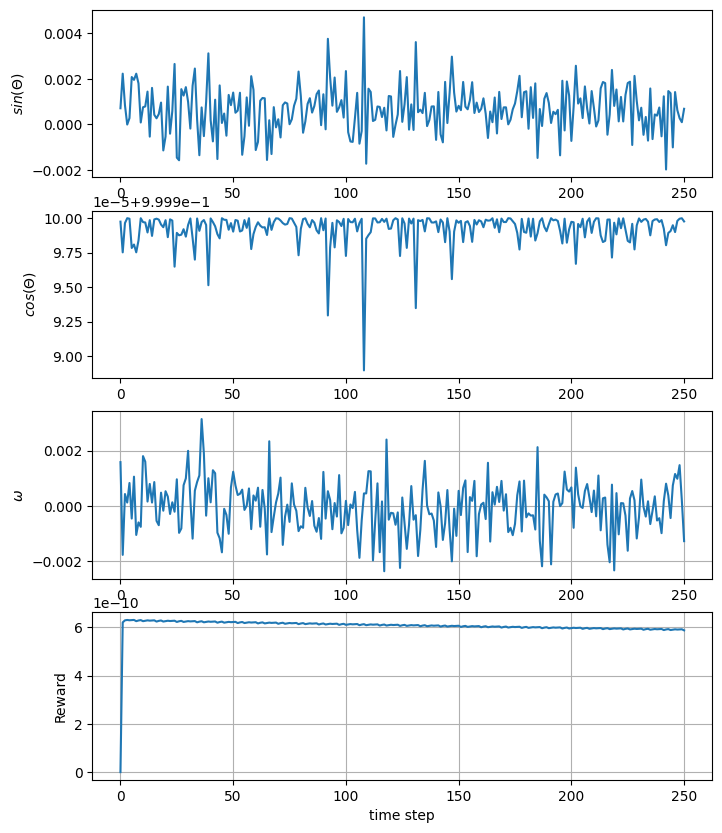

In [20]:
#visualize
def show(Q,env):
    with torch.no_grad():
        #you can use Qfun(obs) as a shorthand for the q function.
        Qfun = lambda x: Q(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy() #convert x to torch.tensor -> put in the Q function -> back to numpy
        try:
            obs, info = env.reset() #b)
            Y = [obs]
            Rewards = [0]
            env.render() #b)
            time.sleep(1) #b)
            while True: #b)
                action = np.argmax(Qfun(obs)) #b)
                obs, reward, terminated, truncated, info = env.step(action) #b)
                Y.append(obs)
                Rewards.append(reward)
                time.sleep(1/60) #b)
                env.render() #b)
                # print(f'sin(theta)={obs[0]:.2f}, cos(theta)={obs[1]:.2f}, omega={obs[2]:.2f}, reward={reward:.4f}')
                if terminated or truncated: #b)
                    time.sleep(0.5)  #b)
                    break  #b)
        finally: #this will always run even when an error occurs
            env.close()
    
    Y = np.array(Y)
    Rewards = np.array(Rewards)
    fig, axs = plt.subplots(4, 1, figsize=(8, 10))
    axs[0].plot(Y[:,0])
    axs[0].set_ylabel(f'$sin(\\Theta)$')
    axs[1].plot(Y[:,1])
    axs[1].set_ylabel(f'$cos(\\Theta)$')
    axs[2].plot(Y[:,2])
    axs[2].set_ylabel(f'$\\omega$')
    axs[2].grid()
    axs[3].plot(Rewards)
    axs[3].set_ylabel('Reward')
    axs[3].grid()
    axs[3].set_xlabel('time step')
    plt.show()

max_episode_steps = 250
env = UnbalancedDisk_sincos(dt=0.025)
env = gym.wrappers.TimeLimit(env,max_episode_steps=max_episode_steps) 
Q = DQN(env, state_dim=3, action_dim=5)
show(Q,env)

In [21]:
def rollout(Q, env, epsilon=0.1, N_rollout=10_000): 
    #save the following (use .append)
    Start_state = [] #hold an array of (x_t)
    Actions = [] #hold an array of (u_t)
    Rewards = [] #hold an array of (r_{t+1})
    End_state = [] #hold an array of (x_{t+1})
    Terminal = [] #hold an array of (terminal_{t+1})
    # Qfun( a numpy array of the obs) -> a numpy array of Q values
    Qfun = lambda x: Q(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy() 
    with torch.no_grad():
        
        obs, info = env.reset() #c)
        for i in range(N_rollout): #c)
            if np.random.uniform()>epsilon: #c)
                Qnow = Qfun(obs) #c)
                action = np.argmax(Qnow) #c)
            else: #c)
                action = env.action_space.sample() #c)
            Start_state.append(obs) #c)
            Actions.append(action) #c)

            obs_next, reward, terminated, truncated, info = env.step(action) #c)

            Terminal.append(terminated) #c)
            Rewards.append(reward) #c)
            End_state.append(obs_next) #c)

            if terminated or truncated: #c)
                obs, info = env.reset() #c)
            else: #c)
                obs = obs_next #c)
                
    #error checking:
    assert len(Start_state)==len(Actions)==len(Rewards)==len(End_state)==len(Terminal), f'error in lengths: {len(Start_state)}=={len(Actions)}=={len(Rewards)}=={len(End_state)}=={len(Dones)}'
    return np.array(Start_state), np.array(Actions), np.array(Rewards), np.array(End_state), np.array(Terminal).astype(int)

max_episode_steps = 250
env = UnbalancedDisk_sincos(dt=0.025)
env = gym.wrappers.TimeLimit(env,max_episode_steps=max_episode_steps)
Q = DQN(env)
Start_state, Actions, Rewards, End_state, Terminal = rollout(Q,env,N_rollout=300)
print(Start_state, Actions, Rewards, End_state, Terminal)

[[ 2.77346677e-04  9.99999962e-01  1.85584714e-04]
 [ 2.52328581e-02  9.99681601e-01  1.89531900e+00]
 [ 9.46249970e-02  9.95512988e-01  3.58490012e+00]
 [ 2.00717034e-01  9.79649260e-01  4.93646824e+00]
 [ 3.30054734e-01  9.43961796e-01  5.86424431e+00]
 [ 4.70051576e-01  8.82638950e-01  6.32577009e+00]
 [ 6.05577543e-01  7.95786303e-01  6.34046896e+00]
 [ 7.20315769e-01  6.93646303e-01  5.95608011e+00]
 [ 8.10790879e-01  5.85335930e-01  5.25827814e+00]
 [ 8.75598005e-01  4.83040509e-01  4.34045643e+00]
 [ 9.17669606e-01  3.97344301e-01  3.28813121e+00]
 [ 9.42762835e-01  3.33463998e-01  2.16130067e+00]
 [ 9.54844845e-01  2.97104901e-01  1.01564663e+00]
 [ 9.54727390e-01  2.97482118e-01 -9.59733222e-01]
 [ 9.39738275e-01  3.41894683e-01 -2.73956187e+00]
 [ 8.94147616e-01  4.47772309e-01 -6.45084213e+00]
 [ 7.85024452e-01  6.19464777e-01 -9.80350642e+00]
 [ 5.81547855e-01  8.13512196e-01 -1.25574157e+01]
 [ 2.78694503e-01  9.60379807e-01 -1.44172819e+01]
 [-8.89315174e-02  9.96037743e-

In [22]:
def eval_Q(Q,env):
    with torch.no_grad():
        Qfun = lambda x: Q(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy()
        rewards_acc = 0 #d)
        obs, info = env.reset() #d)
        while True: #d)
            action = np.argmax(Qfun(obs)) #d)
            obs, reward, terminated, truncated, info = env.step(action) #d)
            rewards_acc += reward #d)
            if terminated or truncated: #d)
                return rewards_acc #d)


In [ ]:
def DQN_rollout(Q, optimizer, env, gamma=0.98, use_target_net=False, N_iterations=21, N_rollout=20000, \
                N_epochs=10, batch_size=32, N_evals=10, target_net_update_feq=100):
    """
    Trains the Deep Q Network (DQN) using the rollout data.
    """
    best = -float('inf')
    torch.save(Q.state_dict(),'Q-checkpoint-nb')
    try:
        for iteration in range(N_iterations):
            epsilon = 1.0 - iteration/(N_iterations-1) #e=) 1.
            print(f'Rollout iter={iteration:2d} with epsilon={epsilon:.2%}...')
            
            #2. rollout
            Start_state, Actions, Rewards, End_state, Terminal = rollout(Q, env, epsilon=epsilon, N_rollout=N_rollout) #e) 2.
            
            #Data conversion, no changes required
            convert = lambda x: [torch.tensor(xi,dtype=torch.float32) for xi in x]
            Start_state, Rewards, End_state, Terminal = convert([Start_state, Rewards, End_state, Terminal])
            Actions = Actions.astype(int)

            t = 0
            for epoch in tqdm(range(N_epochs), desc='Training Epochs'):
                for i in range(batch_size,len(Start_state)+1,batch_size): 
                    if t%target_net_update_feq==0:
                        Qtarget = deepcopy(Q) #g)
                        pass
                    t += 1
                    
                    Start_state_batch, Actions_batch, Rewards_batch, End_state_batch, Terminal_batch = [d[i-batch_size:i] for d in \
                                                                                                        [Start_state, Actions, Rewards, End_state, Terminal]] #e=) 3.
                    
                    with torch.no_grad(): #3.
                        if use_target_net:
                            pass
                            maxQ = torch.max(Qtarget(End_state_batch),dim=1)[0] #g)
                        else:
                            maxQ = torch.max(Q(End_state_batch),dim=1)[0] #e=) 3.
                    
                    # action_index = np.stack((np.arange(batch_size),Actions_batch),axis=0)
                    # ids = np.arange(batch_size)
                    
                    Qnow = Q(Start_state_batch)
                    # print(f'{action_index.shape=}')
                    # print(f'{Qnow.shape=}')
                    Qnow = Qnow[np.arange(batch_size), Actions_batch] #Q(x_t,u_t) is given
                    # print(Rewards_batch.shape, maxQ.shape, Terminal_batch.shape, Qnow.shape)
                    Loss = torch.mean((Rewards_batch + gamma*maxQ*(1-Terminal_batch) - Qnow)**2) #e) 3.
                    optimizer.zero_grad() #e) 3.
                    Loss.backward() #e) 3.
                    optimizer.step() #e) 3.
                
                score = np.mean([eval_Q(Q,env) for i in range(N_evals)]) #e=) 3.
                
                # print(f'iteration={iteration} epoch={epoch} Average Reward per episode:',score)
                if score>best:
                    best = score
                    print('################################# \n new best',best,'saving Q... \n#################################')
                    torch.save(Q.state_dict(),'Q-checkpoint-nb')
            
            print('loading best result')
            Q.load_state_dict(torch.load('Q-checkpoint-nb'))
    finally: #this will always run even when using the a KeyBoard Interrupt. 
        print('loading best result')
        Q.load_state_dict(torch.load('Q-checkpoint-nb'))

## Train the DQN

In [31]:
max_episode_steps = 250
env = UnbalancedDisk_sincos(dt=0.025)
env = gym.wrappers.TimeLimit(env,max_episode_steps=max_episode_steps)

gamma = 0.98 #f=)
batch_size = 32 #f=)
N_iterations = 21 #f=)
N_rollout = 20000 #f=)
N_epochs = 10 #f=)
N_evals = 5 #f=)
lr = 0.0005 #given

assert isinstance(env.action_space,gym.spaces.Discrete), 'action space requires to be discrete'
Qtrained = DQN(env, state_dim=3, action_dim=5)
optimizer = torch.optim.Adam(Qtrained.parameters(),lr=lr) #low learning rate
DQN_rollout(Qtrained, optimizer, env, use_target_net=True, gamma=gamma, N_iterations=N_iterations, \
            N_rollout=N_rollout, N_epochs=N_epochs, N_evals=N_evals)

Rollout iter= 0 with epsilon=100.00%...


Training Epochs:  10%|█         | 1/10 [00:04<00:40,  4.46s/it]

################################# 
 new best 1.2847669567232258e-07 saving Q... 
#################################


Training Epochs: 100%|██████████| 10/10 [00:12<00:00,  1.23s/it]


loading best result
Rollout iter= 1 with epsilon=95.00%...


...

Training Epochs: 100%|██████████| 10/10 [00:44<00:00,  4.49s/it]


loading best result
Rollout iter= 8 with epsilon=60.00%...


Training Epochs:  50%|█████     | 5/10 [00:25<00:25,  5.11s/it]


loading best result


KeyboardInterrupt: 

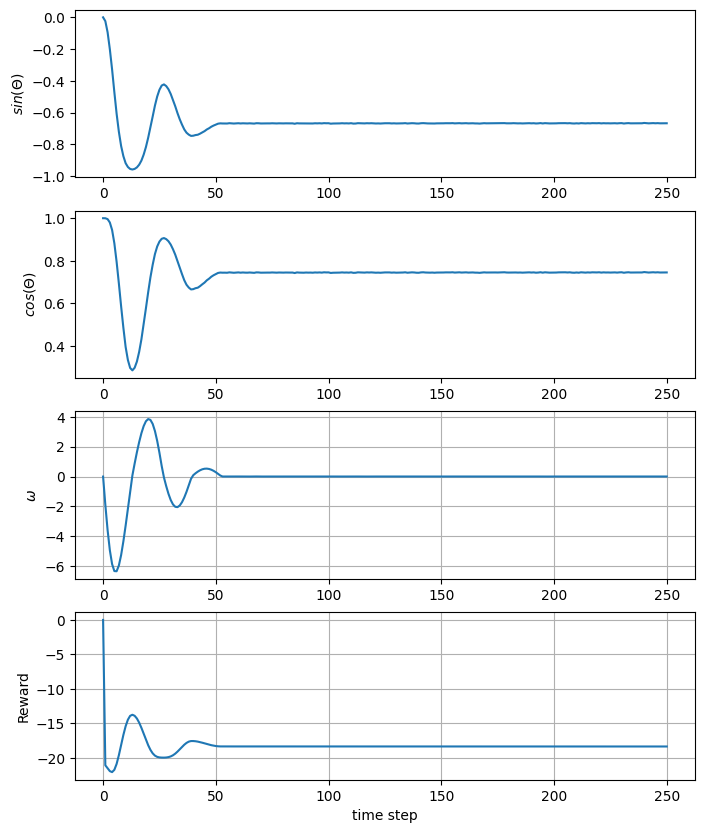

In [29]:
max_episode_steps = 250
env_vis = UnbalancedDisk_sincos(dt=0.025)
env_vis = gym.wrappers.TimeLimit(env_vis,max_episode_steps=max_episode_steps)
show(Qtrained,env_vis)

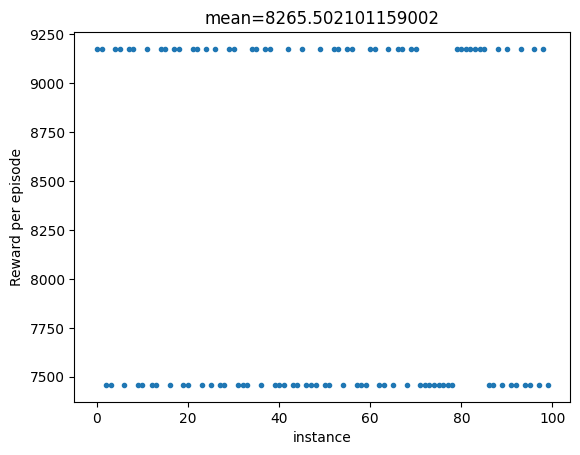

In [12]:
Rewards = [eval_Q(Qtrained,env) for i in range(100)]
plt.plot(Rewards,'.')
plt.title(f'mean={np.mean(Rewards)}')
plt.xlabel('instance')
plt.ylabel('Reward per episode')
plt.show()